In [1]:
import numpy as np
import matplotlib.pyplot as plt

Ejercicio 22. Realizar un diagrama de fases 3D del sistema dado por el modelo SIR del
Ejercicio 10

In [7]:
def sistema(estado, beta, gamma, N):
    s, i, r = estado
    dSdt = -beta * (s*i)/N
    dIdt = beta * (s*i)/N - gamma * i
    dRdt = gamma * i

    return np.array([dSdt, dIdt, dRdt])


def euler(s0, i0, r0, beta, gamma, N, t0, tf, h):
  num_pasos = int((tf-t0) / h)
  t = np.linspace(t0, tf, num_pasos+1)

  S = np.zeros(num_pasos+1)
  S[0] = s0
  I = np.zeros(num_pasos+1)
  I[0] = i0
  R = np.zeros(num_pasos+1)
  R[0] = r0


  for k in range(num_pasos):
    estado = np.array([S[k], I[k], R[k]])
    pendiente = sistema(estado, beta, gamma, N)
    S[k+1] = S[k] + h * pendiente[0]
    I[k+1] = I[k] + h * pendiente[1]
    R[k+1] = R[k] + h * pendiente[2]


  return t, S, I, R

In [16]:
tiempos, susceptibles, infectados, recuperados = euler(44999999, 1, 0, 0.3, 0.1, 45000000, 0, 100, 0.1)

print(f'Al cabo de {tiempos[-1]:.0f} días quedan {susceptibles[-1]:.0f} personas susceptibles, {infectados[-1]:.0f} personas infectadas y {recuperados[-1]:.0f} personas recuperadas')

Al cabo de 100 días quedan 8048882 personas susceptibles, 11225943 personas infectadas y 25725175 personas recuperadas


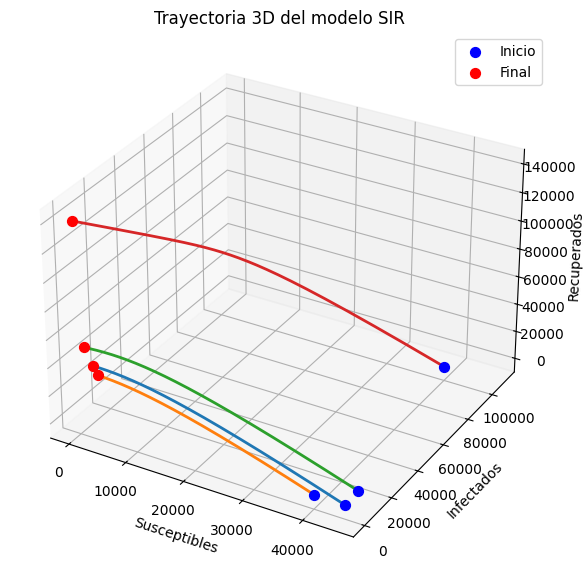

In [24]:
from mpl_toolkits.mplot3d import Axes3D

# Parámetros
beta = 0.3
gamma = 0.1
N = 45000

cond_iniciales = [[44999, 1], [40000, 100], [44999, 10000], [40000, 100000]]

# Gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for k, cond_i in enumerate(cond_iniciales):
    s0, i0 = cond_i
    r0 = 0
    # Solución
    t, S, I, R = euler(s0, i0, r0, beta, gamma, N, 0, 1000, 0.1)

    ax.plot(S, I, R, linewidth=2)

    if k == 0:
        ax.scatter(S[0], I[0], R[0], s=50, color='blue', label='Inicio')
        ax.scatter(S[-1], I[-1], R[-1], s=50, color='red', label='Final')
    else:
        ax.scatter(S[0], I[0], R[0], s=50, color='blue')
        ax.scatter(S[-1], I[-1], R[-1], s=50, color='red')

ax.set_xlabel('Susceptibles')
ax.set_ylabel('Infectados')
ax.set_zlabel('Recuperados')
ax.set_title('Trayectoria 3D del modelo SIR')
ax.legend()

plt.show()
    